In [2]:
import pandas as pd
import numpy as np

feats = pd.read_csv("../../dataset/match_features_merged.csv")
labels = pd.read_csv("../../cleaned_data/final_dataset.csv",
                     usecols=["game_id", "result"])

df = feats.merge(labels, on="game_id")

# keep only rows we can classify
label_map = {"Home Win": 0, "Draw": 1, "Away Win": 2}
df = df[df["result"].isin(label_map)]

print(df.shape)
print("label counts:\n", df["result"].value_counts())

(59605, 55)
label counts:
 result
Home Win    26891
Away Win    18429
Draw        14285
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1 · build raw feature frame (no cleaning yet)
raw_X = df.drop(columns=["game_id", "result"])

# --- count bad values BEFORE cleaning -----------------
n_nan = raw_X.isna().sum().sum()
n_inf = np.isinf(raw_X.values).sum()
print(f"before  –  NaN:{n_nan:,}   ±inf:{n_inf:,}")

# --- clean -------------------------------------------
X_df = (
    raw_X.replace([np.inf, -np.inf], np.nan)          # turn ±inf → NaN
         .fillna(raw_X.mean(numeric_only=True))       # mean-impute
)

# --- count AFTER cleaning ----------------------------
n_nan2 = X_df.isna().sum().sum()
n_inf2 = np.isinf(X_df.values).sum()
print(f"after   –  NaN:{n_nan2:,}   ±inf:{n_inf2:,}")

# 2 · labels -------------------------------------------
y = df["result"].map({"Home Win": 0, "Draw": 1, "Away Win": 2}).astype("int8")

# 3 · split & scale -----------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X_df.values.astype(float), y,
    test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
X_te = scaler.transform(X_te)

# 4 · final safety pass -------------------------------
X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)


# extreme lange fix (-33~51)
CLIP = 7          # ±10 → exp(±10) ≈ 2.2 × 10⁴  (still safe)

X_tr = np.clip(X_tr, -CLIP, CLIP)
X_te = np.clip(X_te, -CLIP, CLIP)

print("train-shape:", X_tr.shape,
      "finite?",    np.isfinite(X_tr).all(),
      "min/max:",   X_tr.min(), X_tr.max())

before  –  NaN:0   ±inf:0
after   –  NaN:0   ±inf:0
train-shape: (47684, 53) finite? True min/max: -7.0 7.0


In [4]:

import pymc as pm
import pytensor.tensor as pt


n, k = X_tr.shape
n_cat = 3          # Home / Draw / Away


# params for data balancing (weighted likelihoods)
# assume y_tr is 0/1/2
counts = np.bincount(y_tr)
weights = counts.max()/counts  # inverse freq
row_w = weights[y_tr]  # per-row weights


with pm.Model() as flat_logit:
    # shared design-matrix so we can swap test data later
    X_ = pm.MutableData("X", X_tr)

    # moderately‐tight, zero-centred priors
    beta = pm.Normal("beta", 0.0, 0.5, shape=(k, n_cat-1))
    intercept = pm.Normal("intercept", 0.0, 0.5, shape=(n_cat-1,))

    # liniear-predictor -> full logits (add class-0 col of zeros)
    eta = intercept + pt.dot(X_, beta)          # (n, 2)
    zeros = pt.zeros_like(eta[:, :1])
    eta_full = pt.concatenate([zeros, eta], axis=1)

    # weighted likelihood
    w = pm.Data("row_w", row_w)  # row weigths (n,)
    cat_rv = pm.Categorical.dist(logit_p=eta_full)
    logp = pm.logp(cat_rv, y_tr)
    pm.Potential("class_weighted", logp*w)
    p = pm.math.softmax(eta_full)
    pm.Deterministic("p", p)

    # ---- safe starting point ----
    # start = pm.find_MAP()             # deterministic mode
    trace = pm.sample(
        # draws=1_000, tune=1_000,
        draws=100, tune=100,
        cores=4,  # at most 4
        # initvals=start,                # jittered around MAP
        init="jitter+adapt_diag",
        target_accept=0.9,
        # chains=4,
        chains=2,
        progressbar=True
    )

/opt/homebrew/Caskroom/miniforge/base/envs/pgm/lib/python3.11/site-packages/pymc/data.py:321: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, intercept]


Output()

Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 866 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: >

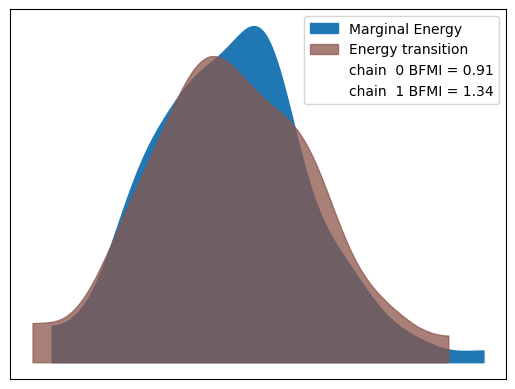

In [5]:
# verify sampled data
import arviz as az
az.summary(trace, var_names=["beta", "intercept"])
az.plot_energy(trace)        # Monte-Carlo standard error & divergences

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
with flat_logit:
    X_.set_value(X_te)                       # swap test matrix
    ppc = pm.sample_posterior_predictive(
        trace, var_names=["p"], return_inferencedata=False)


p_mean = ppc["p"].mean(axis=(0, 1))
y_pred = np.argmax(p_mean, axis=1).astype(np.int8)

print(classification_report(y_te, y_pred, digits=3))
print(confusion_matrix(y_te, y_pred))


bal_acc = balanced_accuracy_score(y_te, y_pred)
print(f"Balanced accuracy: {bal_acc:.3f}")

# quick, self-contained ECE util


def ece(conf, correct, n_bins=10):
    bins = np.linspace(0., 1., n_bins + 1)
    bin_idx = np.digitize(conf, bins, right=True) - 1
    ece = 0.0
    for i in range(n_bins):
        mask = bin_idx == i
        if mask.any():
            acc_i = correct[mask].mean()
            conf_i = conf[mask].mean()
            ece += np.abs(acc_i - conf_i) * mask.mean()   # weight = n_i/N
    return ece


conf = p_mean.max(1)                   # scalar confidence per sample
correct = (p_mean.argmax(1) == y_te)      # 0/1
print("ECE =", ece(conf, correct, n_bins=10))

/var/folders/8j/f7hry10s1sgf5dmy023w1qm40000gn/T/ipykernel_29158/1822484924.py:6: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  ppc = pm.sample_posterior_predictive(
Sampling: []


Output()

              precision    recall  f1-score   support

           0      0.642     0.571     0.604      5378
           1      0.295     0.305     0.300      2857
           2      0.500     0.567     0.531      3686

    accuracy                          0.506     11921
   macro avg      0.479     0.481     0.479     11921
weighted avg      0.515     0.506     0.509     11921

[[3073 1213 1092]
 [ 991  871  995]
 [ 726  871 2089]]
Balanced accuracy: 0.481
ECE: 0.506
